In [8]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("clmentbisaillon/fake-and-real-news-dataset")

print("Path to dataset files:", path)

100%|██████████| 41.0M/41.0M [00:00<00:00, 138MB/s]

Extracting files...


Path to dataset files: /root/.cache/kagglehub/datasets/clmentbisaillon/fake-and-real-news-dataset/versions/1


In [9]:
import pandas as pd
from sklearn.model_selection import train_test_split

In [10]:
import os

# The 'path' variable from the previous cell contains the directory to the dataset.
# We need to find the actual CSV file inside this directory.
print(f"Contents of the dataset directory '{path}':")
for file_name in os.listdir(path):
    print(f"- {file_name}")

# Assuming 'True.csv' is one of the files within the dataset directory.
# If there are other CSV files, you might need to adjust this filename.
file_to_read = os.path.join(path, 'True.csv')

df_true = pd.read_csv(file_to_read)
print(f"Successfully loaded '{file_to_read}' into a DataFrame.")

Contents of the dataset directory '/root/.cache/kagglehub/datasets/clmentbisaillon/fake-and-real-news-dataset/versions/1':
- Fake.csv
- True.csv
Successfully loaded '/root/.cache/kagglehub/datasets/clmentbisaillon/fake-and-real-news-dataset/versions/1/True.csv' into a DataFrame.


In [11]:
df_true.head()

,title,text,subject,date
0,"As U.S. budget fight looms, Republicans flip t...",WASHINGTON (Reuters) - The head of a conservat...,politicsNews,"December 31, 2017"
1,U.S. military to accept transgender recruits o...,WASHINGTON (Reuters) - Transgender people will...,politicsNews,"December 29, 2017"
2,Senior U.S. Republican senator: 'Let Mr. Muell...,WASHINGTON (Reuters) - The special counsel inv...,politicsNews,"December 31, 2017"
3,FBI Russia probe helped by Australian diplomat...,WASHINGTON (Reuters) - Trump campaign adviser ...,politicsNews,"December 30, 2017"
4,Trump wants Postal Service to charge 'much mor...,SEATTLE/WASHINGTON (Reuters) - President Donal...,politicsNews,"December 29, 2017"


In [12]:
df_fake = pd.read_csv('/kaggle/input/fake-and-real-news-dataset/Fake.csv')

In [13]:
df_fake.head()

,title,text,subject,date
0,Donald Trump Sends Out Embarrassing New Year’...,Donald Trump just couldn t wish all Americans ...,News,"December 31, 2017"
1,Drunk Bragging Trump Staffer Started Russian ...,House Intelligence Committee Chairman Devin Nu...,News,"December 31, 2017"
2,Sheriff David Clarke Becomes An Internet Joke...,"On Friday, it was revealed that former Milwauk...",News,"December 30, 2017"
3,Trump Is So Obsessed He Even Has Obama’s Name...,"On Christmas day, Donald Trump announced that ...",News,"December 29, 2017"
4,Pope Francis Just Called Out Donald Trump Dur...,Pope Francis used his annual Christmas Day mes...,News,"December 25, 2017"


In [14]:
df_fake = df_fake.drop(columns=['subject','date'])
df_true = df_true.drop(columns=['subject','date'])

In [15]:
df_true.head()

,title,text
0,"As U.S. budget fight looms, Republicans flip t...",WASHINGTON (Reuters) - The head of a conservat...
1,U.S. military to accept transgender recruits o...,WASHINGTON (Reuters) - Transgender people will...
2,Senior U.S. Republican senator: 'Let Mr. Muell...,WASHINGTON (Reuters) - The special counsel inv...
3,FBI Russia probe helped by Australian diplomat...,WASHINGTON (Reuters) - Trump campaign adviser ...
4,Trump wants Postal Service to charge 'much mor...,SEATTLE/WASHINGTON (Reuters) - President Donal...


In [16]:
df_fake["label"] = 0
df_true["label"] = 1

In [17]:
df_true.head()

,title,text,label
0,"As U.S. budget fight looms, Republicans flip t...",WASHINGTON (Reuters) - The head of a conservat...,1
1,U.S. military to accept transgender recruits o...,WASHINGTON (Reuters) - Transgender people will...,1
2,Senior U.S. Republican senator: 'Let Mr. Muell...,WASHINGTON (Reuters) - The special counsel inv...,1
3,FBI Russia probe helped by Australian diplomat...,WASHINGTON (Reuters) - Trump campaign adviser ...,1
4,Trump wants Postal Service to charge 'much mor...,SEATTLE/WASHINGTON (Reuters) - President Donal...,1


In [18]:
df_fake.shape , df_true.shape

((23481, 3), (21417, 3))

In [19]:
df = pd.concat([df_true , df_fake] ,ignore_index=True)

In [20]:
df.sample(5)

,title,text,label
12485,South Africa's Zuma rejects reports his office...,JOHANNESBURG (Reuters) - South African Preside...,1
4880,Republican lawmakers: health plan tax credit c...,WASHINGTON (Reuters) - U.S. Republicans’ propo...,1
1665,"As clock ticks, Republicans try to move ahead ...",WASHINGTON (Reuters) - The Trump administratio...,1
26831,The RNC’s First Night Proves Republicans Are ...,We ve all heard it from our conservative frien...,0
43273,[VIDEO] #BlackLivesMatter ACTIVIST POSTS STAGE...,Meet Keegan Stephan. He could be Barack Obama ...,0


In [21]:
df.shape

(44898, 3)

In [22]:
df

,title,text,label
0,"As U.S. budget fight looms, Republicans flip t...",WASHINGTON (Reuters) - The head of a conservat...,1
1,U.S. military to accept transgender recruits o...,WASHINGTON (Reuters) - Transgender people will...,1
2,Senior U.S. Republican senator: 'Let Mr. Muell...,WASHINGTON (Reuters) - The special counsel inv...,1
3,FBI Russia probe helped by Australian diplomat...,WASHINGTON (Reuters) - Trump campaign adviser ...,1
4,Trump wants Postal Service to charge 'much mor...,SEATTLE/WASHINGTON (Reuters) - President Donal...,1
...,...,...,...
44893,McPain: John McCain Furious That Iran Treated ...,21st Century Wire says As 21WIRE reported earl...,0
44894,JUSTICE? Yahoo Settles E-mail Privacy Class-ac...,21st Century Wire says It s a familiar theme. ...,0
44895,Sunnistan: US and Allied ‘Safe Zone’ Plan to T...,Patrick Henningsen 21st Century WireRemember ...,0
44896,How to Blow $700 Million: Al Jazeera America F...,21st Century Wire says Al Jazeera America will...,0


In [23]:
df = df.sample(frac=1, random_state=42).reset_index(drop=True)

In [24]:
df.head(10)

,title,text,label
0,BREAKING: GOP Chairman Grassley Has Had Enoug...,"Donald Trump s White House is in chaos, and th...",0
1,Failed GOP Candidates Remembered In Hilarious...,Now that Donald Trump is the presumptive GOP n...,0
2,Mike Pence’s New DC Neighbors Are HILARIOUSLY...,Mike Pence is a huge homophobe. He supports ex...,0
3,California AG pledges to defend birth control ...,SAN FRANCISCO (Reuters) - California Attorney ...,1
4,AZ RANCHERS Living On US-Mexico Border Destroy...,Twisted reasoning is all that comes from Pelos...,0
5,"As private lawyer, Trump high court pick was f...",WASHINGTON (Reuters) - As a lawyer in private ...,1
6,Yemeni Salafist imam killed in Aden: sources,ADEN (Reuters) - A Salafist imam was shot dead...,1
7,FBI says witnesses in U.S. probe into Malaysia...,KUALA LUMPUR (Reuters) - Potential witnesses t...,1
8,An Easy To Read Chart Shows How Bernie Sanders...,The goal of socialism is communism. -Vladimi...,0
9,MMA FIGHTER JAKE SHIELDS Embarrasses Cowards I...,Opposing views and beliefs has much of this co...,0


In [25]:
X = df.iloc[:,0:2]

In [26]:
y = df.iloc[:,2]

In [27]:
y

,label
0,0
1,0
2,0
3,1
4,0
...,...
44893,1
44894,0
44895,0
44896,1


In [28]:
X_train , X_test , y_train , y_test = train_test_split(X,y,test_size=0.2,random_state=1)

In [29]:
X_train.head()

,title,text
19625,Erdogan says Turkey will destroy those in Syri...,ANKARA (Reuters) - President Tayyip Erdogan sa...
21965,Proposed Budget Deal Is MUCH WORSE On U.S. Bor...,"Only a few days after his inauguration, Presid..."
36042,ISRAEL WILL NAME New Train Station Near Wester...,Israel s transportation minister is pushing ah...
27618,HYSTERICAL! Maxine Waters for POTUS? “Oh no! W...,The hysterical Terrence Williams weighs in on ...
25089,Britain's Hammond says 'very confident' of dea...,BRUSSELS (Reuters) - Britain s Chancellor of t...


In [30]:
X_test.head()

,title,text
4528,Construction executives detained in Peru in gr...,LIMA (Reuters) - Four former and current execu...
31727,Brazil speaker says pension overhaul in danger...,BRASILIA (Reuters) - The Brazilian government ...
10937,Sarah Huckabee Sanders Just Said The DUMBEST ...,If you have been vacationing under a rock over...
13470,Irish PM's party says government deal dead if ...,DUBLIN (Reuters) - The deal propping up the Ir...
40814,Insane! Huge Financial Disaster On The Horizon...,I ll bet most Americans have no idea that we r...


In [31]:
y_test

,label
4528,1
31727,1
10937,0
13470,1
40814,0
...,...
6053,0
33584,1
29515,0
33415,0


In [32]:
y_train

,label
19625,1
21965,0
36042,0
27618,0
25089,1
...,...
43723,0
32511,1
5192,1
12172,0


In [33]:
X_test.shape , X_train.shape

((8980, 2), (35918, 2))

In [34]:
y_test.shape , y_train.shape

((8980,), (35918,))

In [35]:
print("Train label dist:\n", y_train.value_counts())
print("Test label dist:\n", y_test.value_counts())

Train label dist:
 label
0    18750
1    17168
Name: count, dtype: int64
Test label dist:
 label
0    4731
1    4249
Name: count, dtype: int64


In [36]:
!pip install tensorflow transformers==4.40.0 --upgrade

KeyboardInterrupt: 

In [37]:
import tensorflow as tf
from transformers import BertTokenizer, TFBertModel
import numpy as np

In [38]:
tokenizer = BertTokenizer.from_pretrained('bert-base-uncased')
bert_model = TFBertModel.from_pretrained('bert-base-uncased')

print("TF:", tf.__version__)
print("BERT loaded successfully!")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/file_download.py:949: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(
Some weights of the PyTorch model were not used when initializing the TF 2.0 model TFBertModel: ['cls.predictions.transform.dense.bias', 'cls.seq_relationship.weight', 'cls.seq_relationship.bias', 'cls.predictions.transform.LayerNorm.weight', 'cls.predictions.transform.dense.weight', 'cls.predictions.bias', 'cls.predictions.transform.LayerNorm.bias']
- This IS expected if you are initializing TFBertModel from a PyTorch model trained on another task or with another architecture (e.g. initializing a TFBertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing TFBertModel from a PyTorch model that you expect to be exactly identical (e.g. initializing a T

TF: 2.21.0
BERT loaded successfully!


In [39]:
print(X_train.iloc[0])

title    Erdogan says Turkey will destroy those in Syri...
text     ANKARA (Reuters) - President Tayyip Erdogan sa...
Name: 19625, dtype: object


In [40]:
print(X_train['text'].iloc[0])

ANKARA (Reuters) - President Tayyip Erdogan said on Tuesday that Turkey will  very soon completely destroy  those in Syria linked to Kurdish militants. Turkey has been angered by U.S. support for Syrian Kurdish YPG fighters who have spearheaded the Western-backed military campaign against Islamic State. Ankara says the YPG is an extension of the outlawed Kurdistan Workers Party (PKK). 


In [41]:
def get_bert_vectors_batch(texts, batch_size=32):
    all_vectors = []
    for i in range(0, len(texts), batch_size):
        batch = texts[i:i+batch_size].tolist()
        inputs = tokenizer(
            batch,
            return_tensors='tf',
            max_length=512,
            truncation=True,
            padding=True
        )
        outputs = bert_model(**inputs)
        vectors = outputs.last_hidden_state[:, 0, :].numpy()
        all_vectors.append(vectors)

        # Progress tracker
        if i % 1000 == 0:
            print(f"Processed {i}/{len(texts)}")

    return np.vstack(all_vectors)

print("Generating train embeddings...")
X_train_vec = get_bert_vectors_batch(X_train['text'])

print("\nGenerating test embeddings...")
X_test_vec = get_bert_vectors_batch(X_test['text'])

print("\nTrain vectors shape:", X_train_vec.shape)
print("Test vectors shape:", X_test_vec.shape)

Generating train embeddings...
Processed 0/35918
Processed 4000/35918
Processed 8000/35918
Processed 12000/35918
Processed 16000/35918
Processed 20000/35918
Processed 24000/35918
Processed 28000/35918
Processed 32000/35918

Generating test embeddings...
Processed 0/8980
Processed 4000/8980
Processed 8000/8980

Train vectors shape: (35918, 768)
Test vectors shape: (8980, 768)


In [42]:
from transformers import TFBertForSequenceClassification
from tensorflow.keras.optimizers import Adam

# Load BERT with classification head
classifier = TFBertForSequenceClassification.from_pretrained(
    'bert-base-uncased',
    num_labels=2        # fake vs true
)

print("Model loaded!")

All PyTorch model weights were used when initializing TFBertForSequenceClassification.

Some weights or buffers of the TF 2.0 model TFBertForSequenceClassification were not initialized from the PyTorch model and are newly initialized: ['classifier.weight', 'classifier.bias']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Model loaded!


In [43]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.optimizers import Adam

# Build model
model = Sequential([
    Dense(256, activation='relu', input_shape=(768,)),
    Dropout(0.3),
    Dense(128, activation='relu'),
    Dropout(0.3),
    Dense(1, activation='sigmoid')  # binary classification
])

model.compile(
    optimizer=Adam(learning_rate=2e-5),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 256)            │       196,864 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 229,889 (898.00 KB)

 Trainable params: 229,889 (898.00 KB)

 Non-trainable params: 0 (0.00 B)

In [44]:
history = model.fit(
    X_train_vec, y_train,
    epochs=5,
    batch_size=32,
    validation_split=0.1,
    verbose=1
)

Epoch 1/5
1011/1011 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.9034 - loss: 0.2559 - val_accuracy: 0.9677 - val_loss: 0.1009
Epoch 2/5
1011/1011 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.9653 - loss: 0.1073 - val_accuracy: 0.9758 - val_loss: 0.0728
Epoch 3/5
1011/1011 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - accuracy: 0.9725 - loss: 0.0835 - val_accuracy: 0.9811 - val_loss: 0.0578
Epoch 4/5
1011/1011 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.9770 - loss: 0.0683 - val_accuracy: 0.9855 - val_loss: 0.0474
Epoch 5/5
1011/1011 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.9797 - loss: 0.0585 - val_accuracy: 0.9875 - val_loss: 0.0396


In [45]:
loss, accuracy = model.evaluate(X_test_vec, y_test, verbose=1)
print(f"Test Accuracy: {accuracy*100:.2f}%")
print(f"Test Loss: {loss:.4f}")

281/281 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9852 - loss: 0.0416
Test Accuracy: 98.52%
Test Loss: 0.0416


In [46]:
from sklearn.metrics import classification_report

y_pred = (model.predict(X_test_vec) > 0.5).astype(int)

print(classification_report(y_test, y_pred, target_names=['Fake', 'True']))

281/281 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
              precision    recall  f1-score   support

        Fake       0.99      0.98      0.99      4731
        True       0.98      0.99      0.98      4249

    accuracy                           0.99      8980
   macro avg       0.99      0.99      0.99      8980
weighted avg       0.99      0.99      0.99      8980



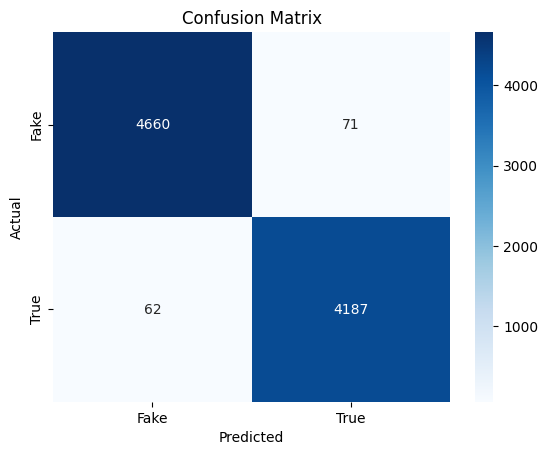

In [47]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Fake', 'True'],
            yticklabels=['Fake', 'True'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

In [48]:
def predict_news(text):
    inputs = tokenizer(
        text,
        return_tensors='tf',
        max_length=512,
        truncation=True,
        padding=True
    )
    outputs = bert_model(**inputs)
    vector = outputs.last_hidden_state[:, 0, :].numpy()

    prediction = model.predict(vector)
    probability = prediction[0][0]

    print(f"Raw prediction value: {probability}")
    print(f"Fake: {(1-probability)*100:.2f}%")
    print(f"True: {probability*100:.2f}%")

In [49]:
predict_news("BREAKING: Modi caught accepting bribes from Pakistan ISI agents, sources confirm") #Rahul Gandhi

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 394ms/step
Raw prediction value: 0.5701183676719666
Fake: 42.99%
True: 57.01%


In [50]:
predict_news("India successfully launched Chandrayaan-3 mission to the moon from Sriharikota")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step
Raw prediction value: 0.22602932155132294
Fake: 77.40%
True: 22.60%


In [51]:
predict_news("Indian government puts secret mind control chips in Aadhaar cards, leaked documents show")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step
Raw prediction value: 0.3242012560367584
Fake: 67.58%
True: 32.42%


In [52]:
predict_news('Councillors to visit controversial site at centre of planning row')

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step
Raw prediction value: 0.04763348028063774
Fake: 95.24%
True: 4.76%


In [53]:
predict_news('In a major push to combat urban pollution, the Delhi Cabinet approved an updated EV policy that exempts electric cars priced up to Rs 30 lakh from road tax and registration fees, and mandates a phased ban on new petrol bikes from 2028')

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step
Raw prediction value: 0.9846400022506714
Fake: 1.54%
True: 98.46%


In [54]:
predict_news('Virat kohli is dead ')

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step
Raw prediction value: 0.1851557195186615
Fake: 81.48%
True: 18.52%


In [55]:
predict_news('Game of thrones Season 9 is coming')

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 99ms/step
Raw prediction value: 0.02290015108883381
Fake: 97.71%
True: 2.29%


In [56]:
predict_news(' The Andhra Pradesh state government has allotted over 120 acres of land in Anantapur to SpaceFields Pvt. Ltd. for a new solid rocket fuel processing facility. In West Bengal, the ISKCON Kolkata center removed its vice president amid ongoing statewide debates regarding eggs being dropped from midday meal schemes.')

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
Raw prediction value: 0.99224853515625
Fake: 0.78%
True: 99.22%


In [57]:
model.save('fake_news_model.keras')
from google.colab import files
files.download('fake_news_model.keras')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [58]:
import numpy as np

# Extract raw matrices and bias vectors directly from your trained model layers
weights_dict = {
    "w1": model.layers[0].get_weights()[0],
    "b1": model.layers[0].get_weights()[1],
    "w2": model.layers[2].get_weights()[0],
    "b2": model.layers[2].get_weights()[1],
    "w3": model.layers[4].get_weights()[0],
    "b3": model.layers[4].get_weights()[1]
}

# Save it as a standard NumPy binary file
np.save("model_numpy_weights.npy", weights_dict)
print("File successfully created!")

File successfully created!
